In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data_airquality.csv")
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x96 in position 154449: invalid start byte

In [3]:
!pip install scikit-learn

In [4]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from sklearn.metrics import accuracy_score,confusion_matrix 
from sklearn.linear_model import LogisticRegression 
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(
    "data_airquality.csv",
    encoding='latin1',
    low_memory=False
) 
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,2/1/1990
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,2/1/1990
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,2/1/1990
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,3/1/1990
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,3/1/1990


In [6]:
#Data cleaning 
df=df.drop_duplicates() 
df.describe()

,so2,no2,rspm,spm,pm2_5
count,400436.000000,418846.000000,395033.000000,198160.000000,9314.000000
mean,10.830468,25.823296,108.871711,220.774796,40.791467
std,11.168994,18.497878,74.898637,151.374791,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [7]:
df.isna().sum()

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149466
type                             5357
so2                             34632
no2                             16222
rspm                            40035
spm                            236908
location_monitoring_station     27303
pm2_5                          425754
date                                7
dtype: int64

In [8]:
percent_missing = df.isnull().sum() * 100 / len(df) 
percent_missing.sort_values(ascending=False)

pm2_5                          97.859185
spm                            54.453097
agency                         34.354630
stn_code                       33.115973
rspm                            9.202010
so2                             7.960135
location_monitoring_station     6.275571
no2                             3.728613
type                            1.231302
date                            0.001609
sampling_date                   0.000690
location                        0.000690
state                           0.000000
dtype: float64

In [9]:
df = df.drop(columns=[
    'stn_code',
    'agency',
    'sampling_date',
    'location_monitoring_station',
    'pm2_5'
], errors='ignore')

df.head()

,state,location,type,so2,no2,rspm,spm,date
0,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,2/1/1990
1,Andhra Pradesh,Hyderabad,Industrial Area,3.1,7.0,NaN,NaN,2/1/1990
2,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,2/1/1990
3,Andhra Pradesh,Hyderabad,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,3/1/1990
4,Andhra Pradesh,Hyderabad,Industrial Area,4.7,7.5,NaN,NaN,3/1/1990


In [10]:
col_var = ['state', 'location', 'type','date'] 
col_num = ['so2','no2','rspm','spm'] 
for col in df.columns: 
    if df[col].dtype == 'object' or df[col].dtype == 'string': 
        df[col] = df[col].fillna(df[col].mode()[0]) 
    else: 
        df[col] = df[col].fillna(df[col].mean())

In [11]:
df.isna().sum()

state       0
location    0
type        0
so2         0
no2         0
rspm        0
spm         0
date        0
dtype: int64

In [12]:
#Data integration 
subSet1 = df[['state', 'type']] 
subSet2 = df[['state','location']] 
subSet1.head()

,state,type
0,Andhra Pradesh,"Residential, Rural and other Areas"
1,Andhra Pradesh,Industrial Area
2,Andhra Pradesh,"Residential, Rural and other Areas"
3,Andhra Pradesh,"Residential, Rural and other Areas"
4,Andhra Pradesh,Industrial Area


In [13]:
subSet2.head()

,state,location
0,Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Hyderabad
2,Andhra Pradesh,Hyderabad
3,Andhra Pradesh,Hyderabad
4,Andhra Pradesh,Hyderabad


In [14]:
concatenated_df = pd.concat([subSet1, subSet2], axis=1) 
concatenated_df

,state,type,state,location
0,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
1,Andhra Pradesh,Industrial Area,Andhra Pradesh,Hyderabad
2,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
3,Andhra Pradesh,"Residential, Rural and other Areas",Andhra Pradesh,Hyderabad
4,Andhra Pradesh,Industrial Area,Andhra Pradesh,Hyderabad
...,...,...,...,...
435737,West Bengal,RIRUO,West Bengal,ULUBERIA
435738,West Bengal,RIRUO,West Bengal,ULUBERIA
435739,andaman-and-nicobar-islands,"Residential, Rural and other Areas",andaman-and-nicobar-islands,Guwahati
435740,Lakshadweep,"Residential, Rural and other Areas",Lakshadweep,Guwahati


In [15]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return column.where((column >= lower) & (column <= upper))

In [16]:
#Remove outliers 
col_name = ['so2', 'no2', 'rspm', 'spm'] 
for col in col_name:    
    df[col] = remove_outliers(df[col])

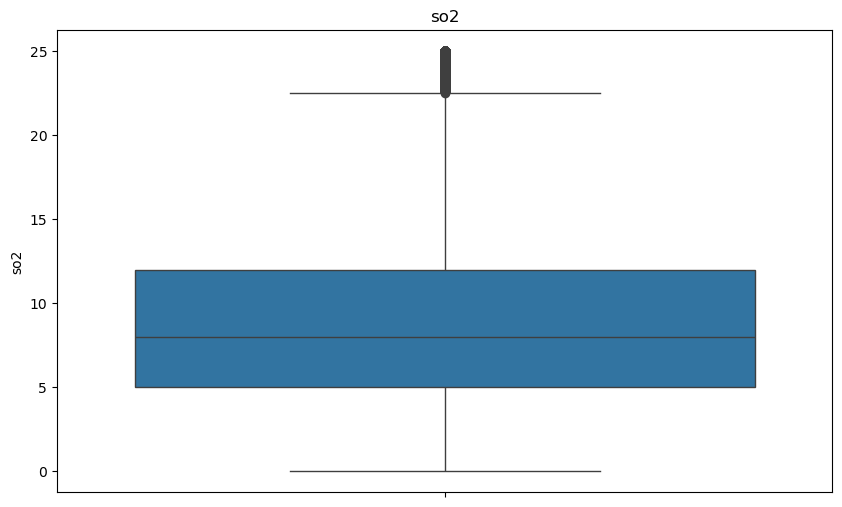

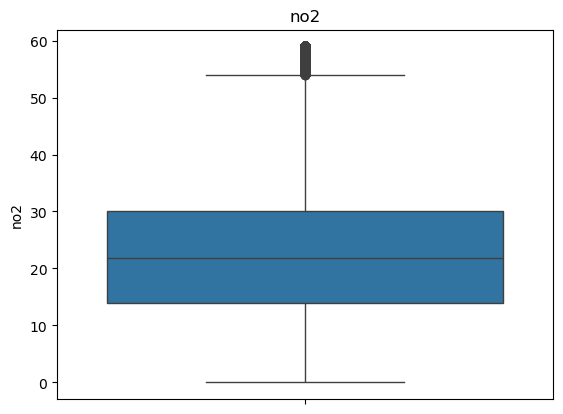

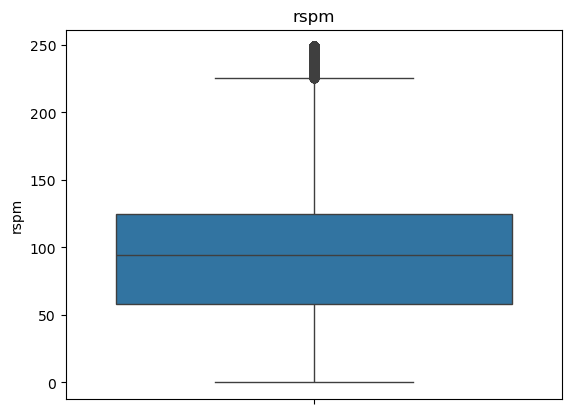

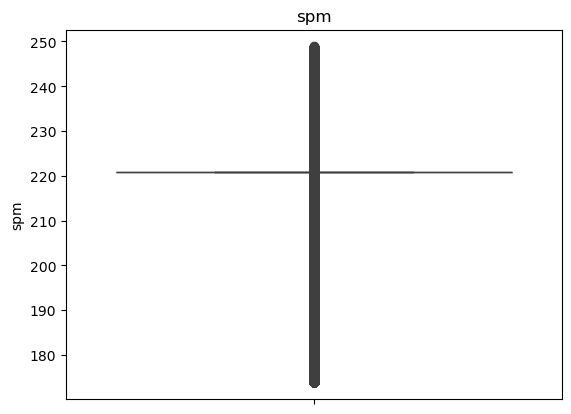

In [17]:
plt.figure(figsize=(10, 6))  
# Adjust the figure size if needed 
for col in col_name:    
    sns.boxplot(data=df[col])    
    plt.title(col)    
    plt.show()

In [18]:
#Data Transform 
from sklearn.preprocessing import LabelEncoder 
col_label= ['state','location','type'] 
# Initialize LabelEncoder
encoder = LabelEncoder() 
# Iterate over columns 
for col in df.columns:        
    # Fit and transform the column       
    df[col] = encoder.fit_transform(df[col])
df

,state,location,type,so2,no2,rspm,spm,date
0,0,114,6,446,1489,2030,464,1693
1,0,114,1,197,250,2030,464,1693
2,0,114,6,790,3096,2030,464,1693
3,0,114,6,823,1144,2030,464,2093
4,0,114,1,427,301,2030,464,2093
...,...,...,...,...,...,...,...,...
435737,35,282,3,2888,5307,2534,464,1505
435738,35,282,3,2809,5113,3098,464,1570
435739,36,100,6,1638,2696,2030,464,2256
435740,17,100,6,1638,2696,2030,464,2256


In [19]:
# splitting data using train test split 
df = df.sample(1000, random_state=0) 
x = df[['so2','no2','spm','rspm']] 
y = df['location'] 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0) 
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((800, 4), (200, 4), (800,), (200,))

In [20]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test)

In [21]:
model = LogisticRegression(max_iter=100) 
model.fit(x_train_scaled, y_train) 
y_pred = model.predict(x_test_scaled) 
from sklearn.metrics import accuracy_score 
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.075


C:\Users\Rohit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
